# Receiver Function (thicknesses)

[![Open In Colab](https://img.shields.io/badge/open%20in-Colab-b5e2fa?logo=googlecolab&style=flat-square&color=ffd670)](https://colab.research.google.com/github/inlab-geo/cofi-examples/blob/main/examples/receiver_function/receiver_function.ipynb)

<!-- Again, please don't touch the markdown cell above. We'll generate badge 
     automatically from the above cell. -->

<!-- This cell describes things related to environment setup, so please add more text 
     if something special (not listed below) is needed to run this notebook -->

> If you are running this notebook locally, make sure you've followed [steps here](https://github.com/inlab-geo/cofi-examples#run-the-examples-with-cofi-locally)
to set up the environment. (This [environment.yml](https://github.com/inlab-geo/cofi-examples/blob/main/envs/environment.yml) file
specifies a list of packages required to run the notebooks)

Receiver functions are a class of seismic data used to study discontinuities (layering) in the Earth's crust. At each discontinuity, P-to-S conversions occur, introducing complexity in the waveform. By deconvolving horizontal- and vertical-channel waveforms from earthquakes at teleseismic distances, we can isolate information about these conversions, and hence learn about the crustal structure. This deconvolved signal is the receiver function, and has a highly non-linear dependence on the local crustal properties.

We refer you to the paper below for description of the algorithms and the forward kernel we use:

*Genetic algorithm inversion for receiver functions with application to crust and uppermost mantle structure beneath Eastern Australia*,
Shibutani, T., Kennett, B. and Sambridge, M., Geophys. Res. Lett., 23 , No. 4, 1829-1832, 1996.

In this notebook, we run inversion on a toy model with optimisation and parallel sampling.

## 0. Import modules

In [1]:
# -------------------------------------------------------- #
#                                                          #
#     Uncomment below to set up environment on "colab"     #
#                                                          #
# -------------------------------------------------------- #

# !pip install -U cofi geo-espresso

In [2]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import arviz
import emcee

import cofi
import espresso

In [3]:
# randomness is used to initialise emcee walkers starting points
np.random.seed(42)

We are going to use the receiver function kernel wrapped in 
[`espresso`](https://geo-espresso.readthedocs.io/en/latest/user_guide/contrib/generated/_receiver_function/index.html),
with calls to Fortran routines developed by Takuo Shibutani in the backend.

In [4]:
my_receiver_function = espresso.ReceiverFunctionInversion(example_number=4)

Consider a model setup of `n` layers described with 3 parameters for each layer. `model` is a NumPy array of dimension `[nlayers,3]`. The values in `model[:,0]` give the depths of discontinuities in the model, while `model[:,1]` contains the S-wave speed above the interface. `model[:,2]` is the ratio of S-wave speed to P-wave speed. The maximum depth of discontinuity that can be considered is 60km.

In this example, we fix the ratio of S-wave speed to P-wave speed, and treat the interface depths and velocities of 5 layers as unknowns.

In order to better understand the complexity and non-linear nature of seismic receiver function inversion, we have included a few illustrative animations. These animations highlight the substantial influence of velocities and, more prominently, interface depths on the resulting receiver functions.

![depth_layer3_anim4.gif](https://github.com/inlab-geo/cofi-examples/blob/main/examples/receiver_function/depth_layer3_anim4.gif?raw=true)

![vel_layer3_anim4_400f.gif](https://github.com/inlab-geo/cofi-examples/blob/main/examples/receiver_function/vel_layer3_anim4_400f.gif?raw=true)

This is a non-linear problem which can be highly sensitive to the starting model. 

![3Dsurf_x40y10_v55_l270_35](https://github.com/inlab-geo/cofi-examples/blob/main/examples/receiver_function/3Dsurf_x40y10_v55_l270_35.png?raw=true)

Here we set a starting model that is reasonably close to the true model, so that the optimisation converges.

In [5]:
null_model = my_receiver_function.starting_model 

print(f"Number of model parameters in this example: {null_model.size}")
my_receiver_function._model_setup(null_model)

Number of model parameters in this example: 6


array([[ 9. ,  4. ,  1.7],
       [20. ,  5. ,  1.7],
       [50. ,  6. ,  1.7]])

Let's plot the starting Earth model.

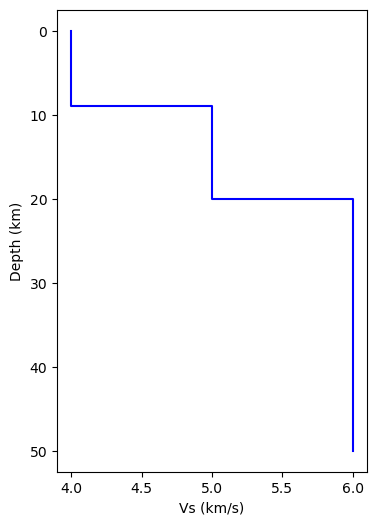

In [6]:
my_receiver_function.plot_model(null_model);

Now we calculate the receiver function and plot it

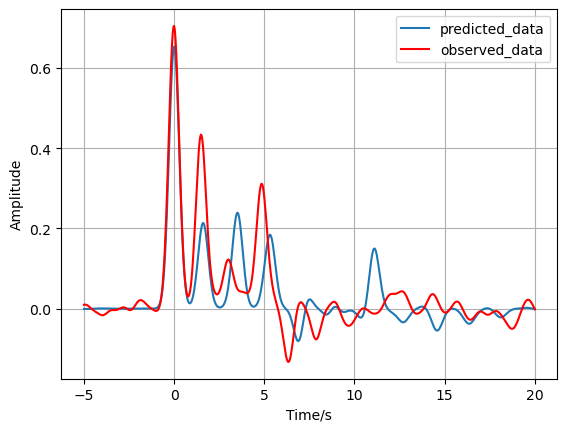

In [7]:
predicted_data = my_receiver_function.forward(null_model)
observed_data = my_receiver_function.data 
my_receiver_function.plot_data(
    data1=predicted_data, 
    data2=observed_data, 
    label="predicted_data", 
    label2="observed_data", 
)
plt.legend();

### 0.1 Utility functions

In `espresso.ReceiverFunctionInversion`, depths are used instead of thickness. 
We would like to use thickness in our inversion instead, so create the following utility
functions setup.

In [8]:
def depth_to_thickness(model):
    depth1, vel1, depth2, vel2, depth3, vel3 = model
    thick1 = depth1
    thick2 = depth2 - depth1
    thick3 = depth3 - depth2
    return np.array([thick1, vel1, thick2, vel2, thick3, vel3])

def thickness_to_depth(model):
    thick1, vel1, thick2, vel2, thick3, vel3 = model
    depth1 = thick1
    depth2 = thick1 + thick2
    depth3 = depth2 + thick3
    return np.array([depth1, vel1, depth2, vel2, depth3, vel3])

## 1. Solve with an optimiser

### 1.1 Define BaseProblem

In [9]:
my_problem = cofi.BaseProblem()

In preparation for optimisation:

In [10]:
def my_misfit(model, include_uncertainty=False):
    model = thickness_to_depth(model)
    predicted_data = my_receiver_function.forward(model)
    misfit_val = my_receiver_function.misfit(predicted_data, observed_data)
    if math.isnan(misfit_val):
        return float("inf")
    return misfit_val

my_problem.set_objective(my_misfit)
my_problem.set_initial_model(depth_to_thickness(null_model))

my_problem.summary()

Summary for inversion problem: BaseProblem
Model shape: (6,)
---------------------------------------------------------------------
List of functions/properties set by you:
['objective', 'initial_model', 'model_shape']
---------------------------------------------------------------------
List of functions/properties created based on what you have provided:
-- none --
---------------------------------------------------------------------
List of functions/properties that can be further set for the problem:
( not all of these may be relevant to your inversion workflow )
['log_posterior', 'log_posterior_with_blobs', 'log_likelihood', 'log_prior', 'gradient', 'hessian', 'hessian_times_vector', 'residual', 'jacobian', 'jacobian_times_vector', 'data_misfit', 'regularization', 'regularization_matrix', 'forward', 'data', 'data_covariance', 'data_covariance_inv', 'blobs_dtype', 'bounds', 'constraints']


### 1.2 Define InversionOptions

In [11]:
my_options_optimiser = cofi.InversionOptions()
my_options_optimiser.set_tool("scipy.optimize.minimize")
my_options_optimiser.set_params(method="Nelder-Mead")   # Nelder-Mead or COBYLA

### 1.3 Define Inversion and run

In [12]:
inv_optimiser = cofi.Inversion(my_problem, my_options_optimiser)
my_result_optimiser = inv_optimiser.run()
my_result_optimiser.summary()

Summary for inversion result
SUCCESS
----------------------------
fun: 282.89335258403463
nit: 259
nfev: 476
status: 0
message: Optimization terminated successfully.
final_simplex: (array([[ 9.55217417,  4.25685804,  9.24894038,  6.11140792, 28.50805414,
         6.34542412],
       [ 9.55217448,  4.25685807,  9.2489399 ,  6.11140796, 28.5080563 ,
         6.34542412],
       [ 9.55217432,  4.25685806,  9.24894029,  6.11140795, 28.50805328,
         6.34542418],
       [ 9.55217439,  4.25685809,  9.24894001,  6.11140796, 28.50805576,
         6.34542411],
       [ 9.55217423,  4.25685806,  9.24894032,  6.11140791, 28.50805435,
         6.34542412],
       [ 9.55217461,  4.2568581 ,  9.24893993,  6.11140795, 28.50805393,
         6.34542421],
       [ 9.55217424,  4.25685804,  9.24894021,  6.11140792, 28.50805508,
         6.34542414]]), array([282.89335258, 282.89335258, 282.89335258, 282.89335258,
       282.89335258, 282.89335258, 282.89335258]))
model: [ 9.55217417  4.25685804  9.24

In [13]:
inverted_model = thickness_to_depth(my_result_optimiser.model)

print("Inversion result:    ", inverted_model)
print("Reference good model:", my_receiver_function.good_model)

Inversion result:     [ 9.55217417  4.25685804 18.80111455  6.11140792 47.30916869  6.34542412]
Reference good model: [ 8.   4.2 20.   6.  45.   6.2]


### 1.4 Plotting

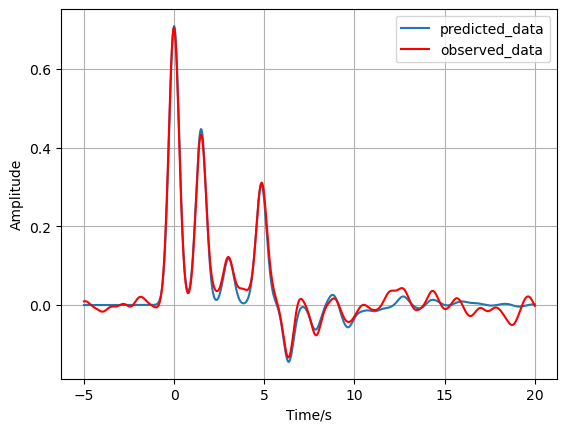

In [14]:
predicted_data = my_receiver_function.forward(inverted_model)
my_receiver_function.plot_data(
    data1=predicted_data, 
    data2=observed_data, 
    label="predicted_data", 
    label2="observed_data", 
)
plt.legend();

## 2. Solve with a sampler

In preparation for sampling:

In [15]:
def my_log_likelihood(model):
    model = thickness_to_depth(model)
    data1 = my_receiver_function.data
    data2 = my_receiver_function.forward(model)
    log_likelihood = my_receiver_function.log_likelihood(data1, data2)
    return log_likelihood

def my_log_prior(model):
    thicknesses_in_0_40 = all([m_p < 40 and m_p > 0 for m_p in model[[0,2,4]]])
    velocities_in_3_7 = all([m_p < 7. and m_p > 3. for m_p in model[[1,3,5]]])
    if thicknesses_in_0_40 and velocities_in_3_7:
        # return -3*np.log(40) -3*np.log(4)
        return 1
    return float("-inf")

In [16]:
ndim = my_receiver_function.model_size
nwalkers = 12
nsteps = 25000
walkers_start = depth_to_thickness(null_model) + 1e-1 * np.random.randn(nwalkers, ndim)

In [17]:
# for plotting labels later
var_names = (
    "thickness1 (km)", 
    "velocity1 (km/s)", 
    "thickness2 (km)", 
    "velocity2 (km/s)", 
    "thickness3 (km)", 
    "velocity3 (km/s)", 
)

### 2.1 Sample the prior distribution

It's a good practice to always sample the prior before you sample the posterior.

Here we use CoFI to define a separate BaseProblem in order to sample the prior, with the "posterior"
(target distribution) set to the prior we've defined above.

In [18]:
sampling_prior_problem = cofi.BaseProblem()
sampling_prior_problem.set_model_shape(ndim)
sampling_prior_problem.set_log_posterior(my_log_prior)

sampling_prior_options = cofi.InversionOptions()
sampling_prior_options.set_tool("emcee")
sampling_prior_options.set_params(
    nwalkers=nwalkers,
    nsteps=nsteps,
    initial_state=walkers_start,
    progress=True,
)

sampling_prior = cofi.Inversion(sampling_prior_problem, sampling_prior_options)
sampling_prior_result = sampling_prior.run()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:07<00:00, 3206.90it/s]


In [19]:
prior_inf_data = sampling_prior_result.to_arviz(var_names=var_names)

#### Trace plot

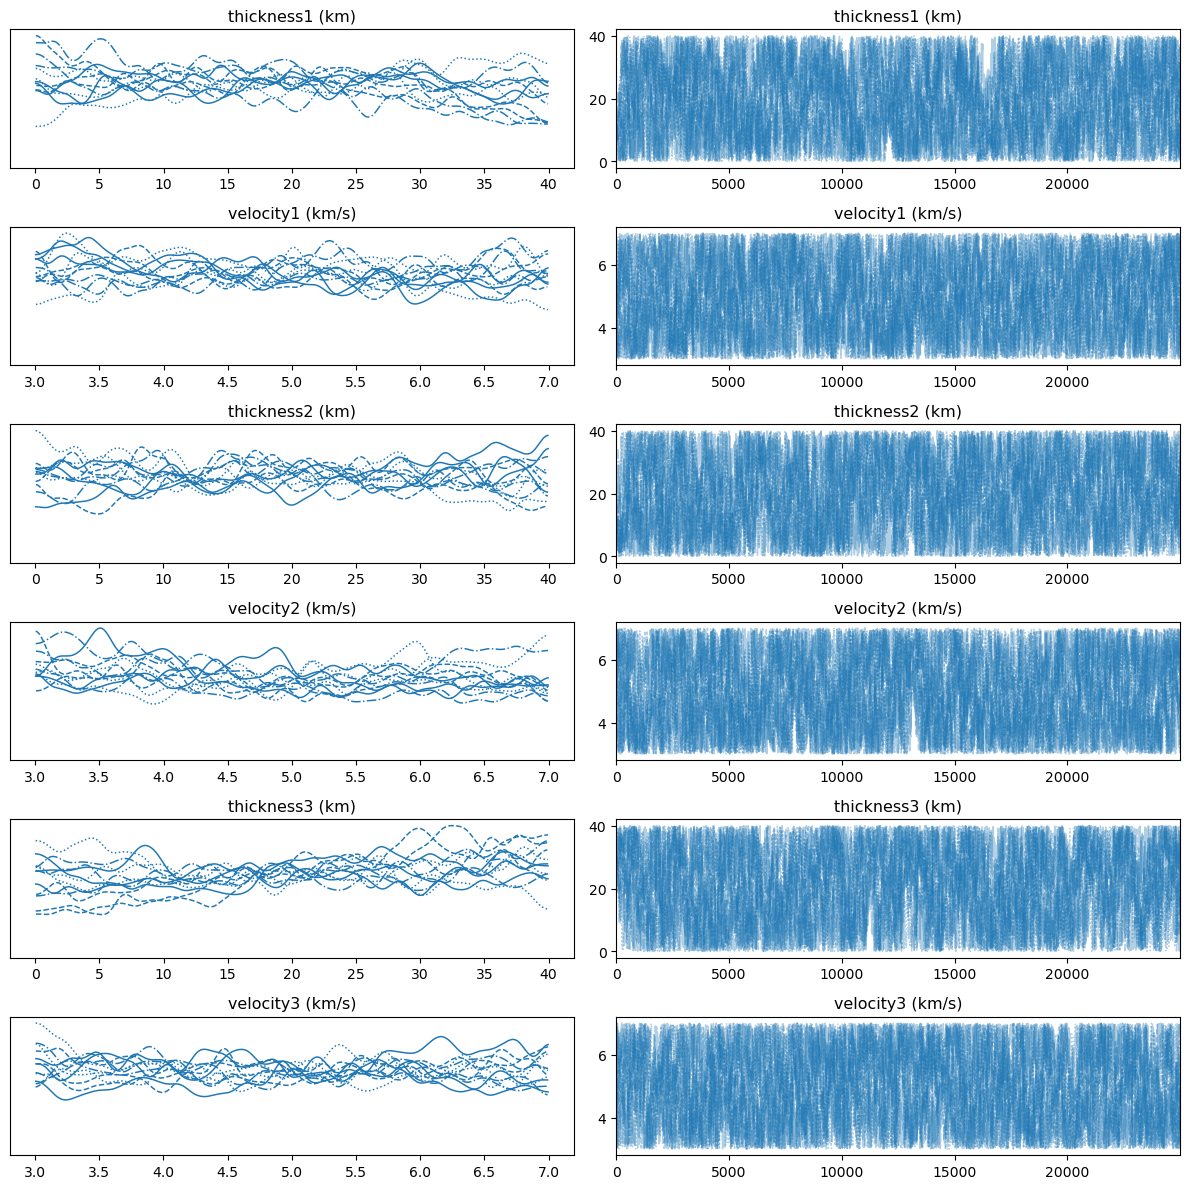

In [20]:
arviz.plot_trace(prior_inf_data)
plt.tight_layout();

#### Autocorrelation time

In [21]:
tau = sampling_prior_result.sampler.get_autocorr_time()
print(f"autocorrelation time: {tau}")

autocorrelation time: [245.52789659 366.37125295 305.3434706  382.51168394 319.84093677
 300.48389809]


#### Corner plot

Let's discard the initial 5000 steps, thin it by every 300 steps and make a corner plot:

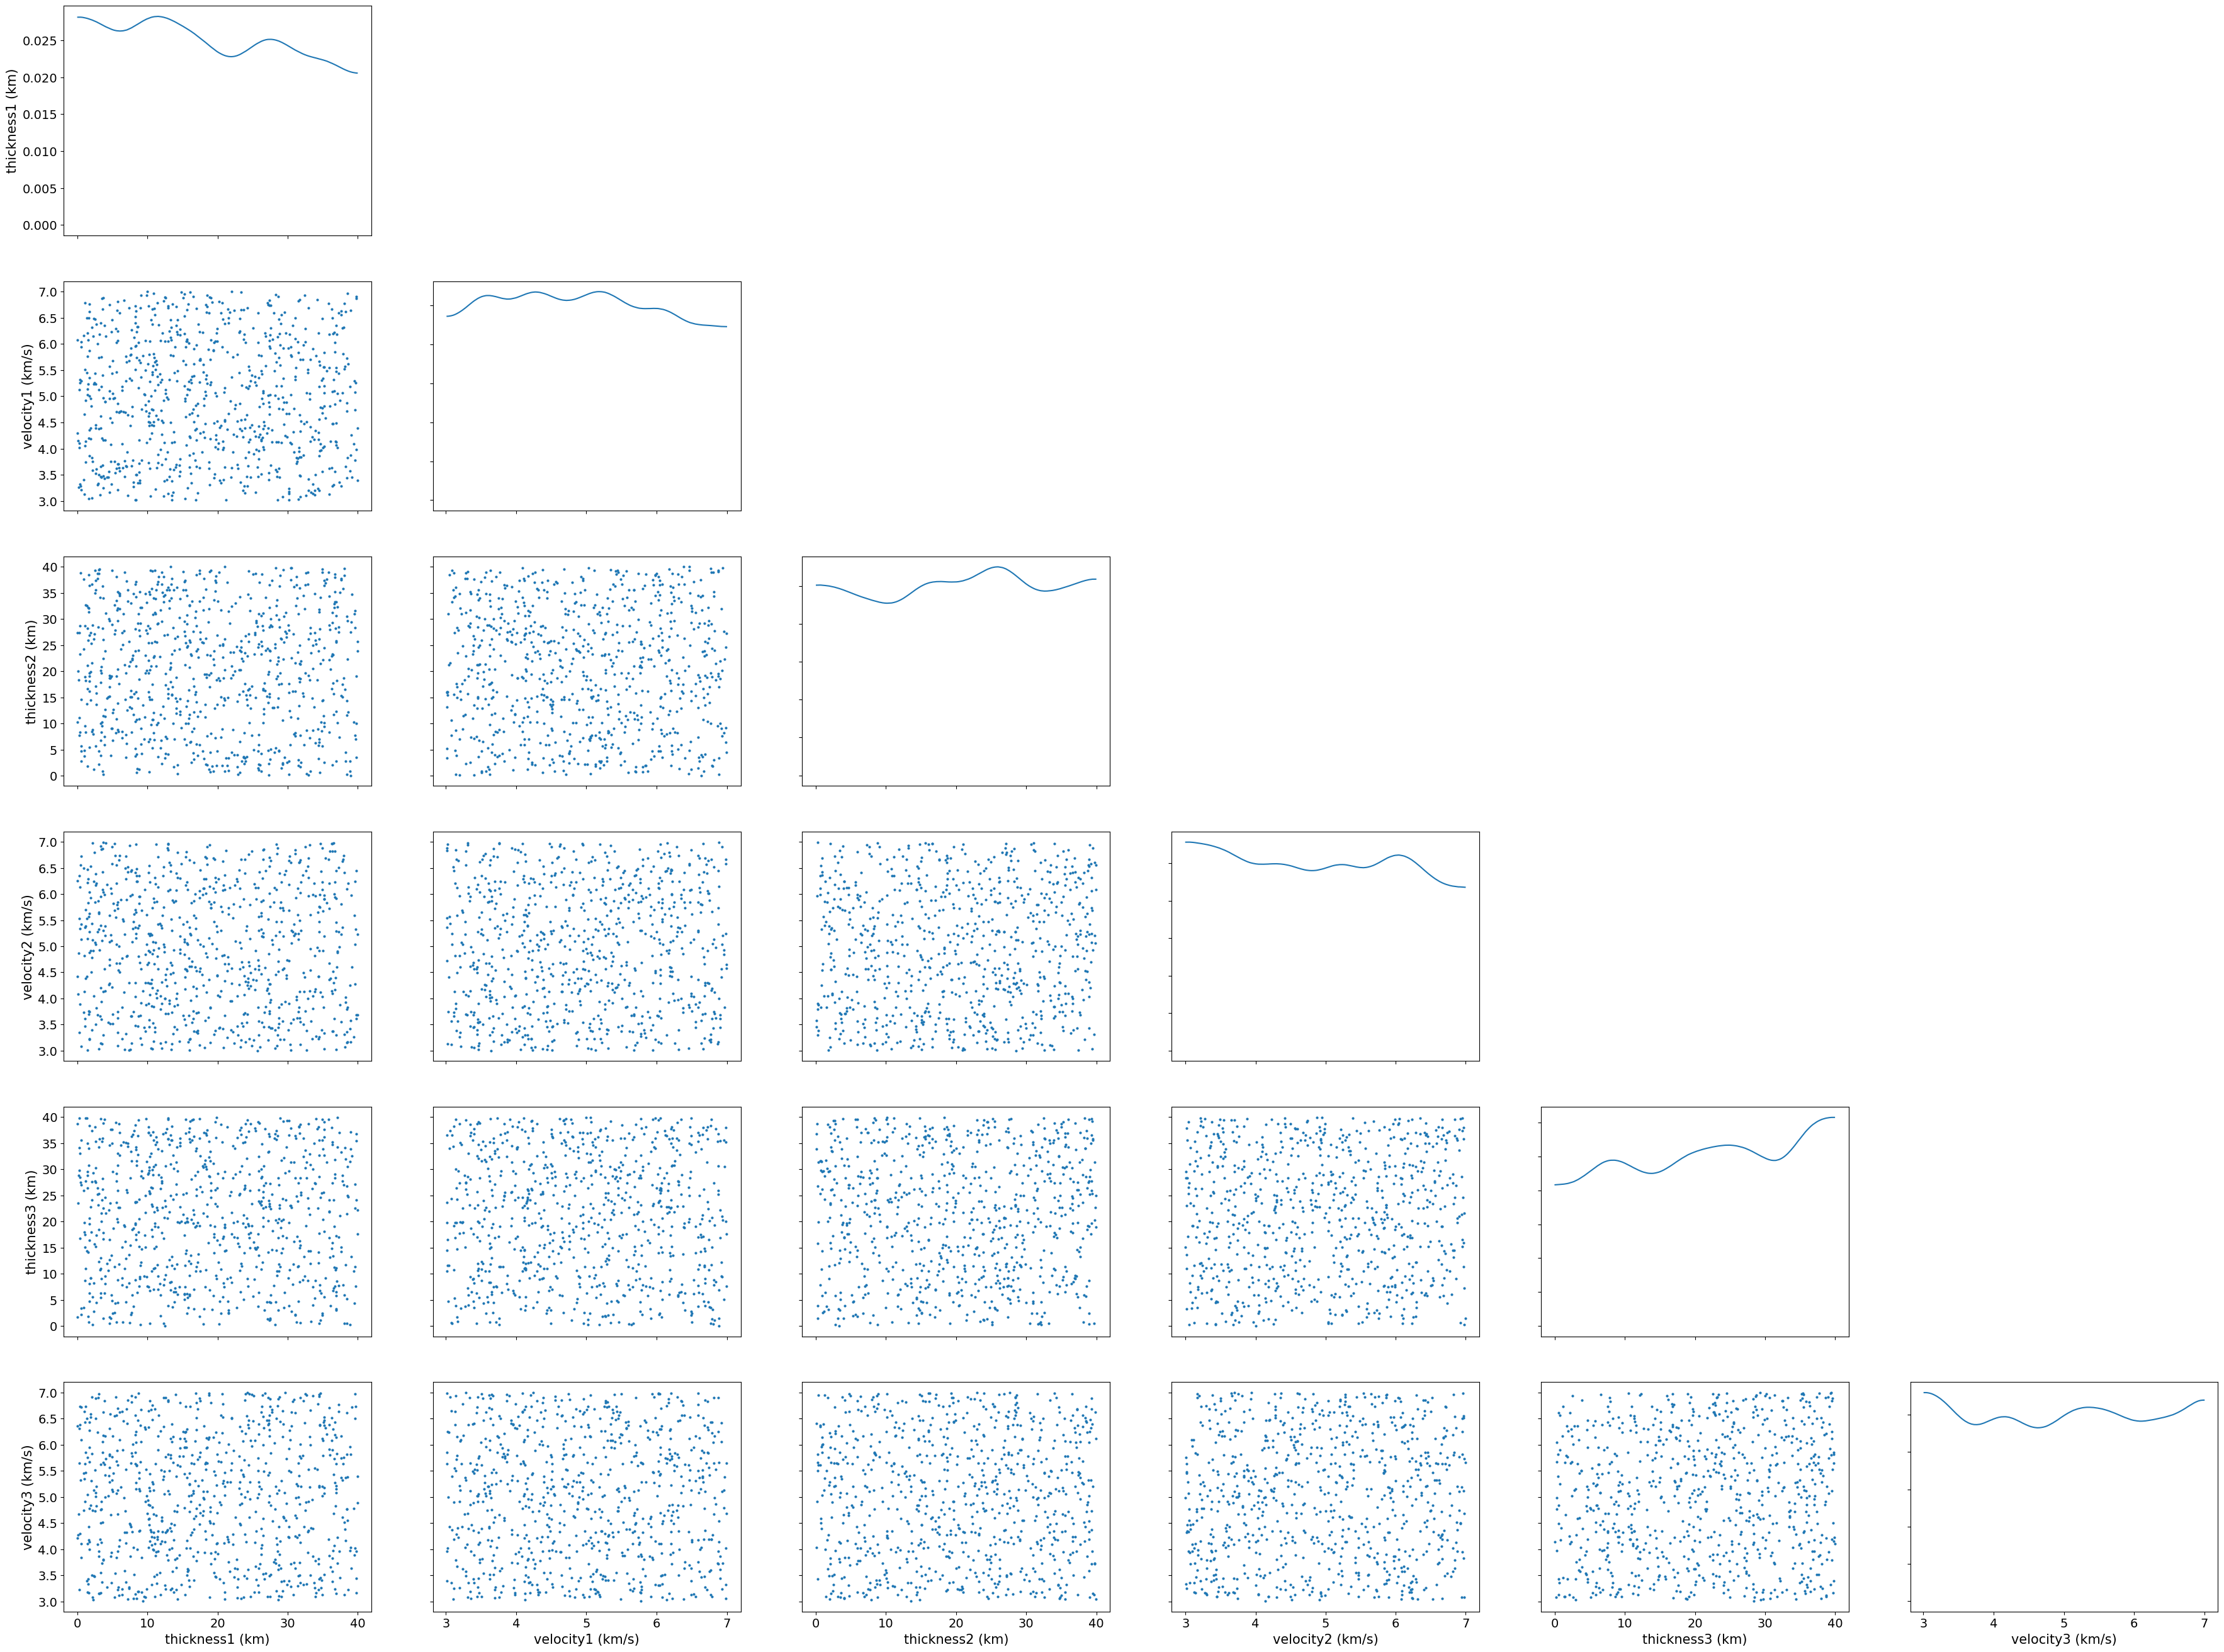

In [22]:
prior_inf_data_after_5000 = prior_inf_data.sel(draw=slice(5000,None,300))
arviz.plot_pair(
    prior_inf_data_after_5000, 
    marginals=True, 
);

#### 1D profile histogram

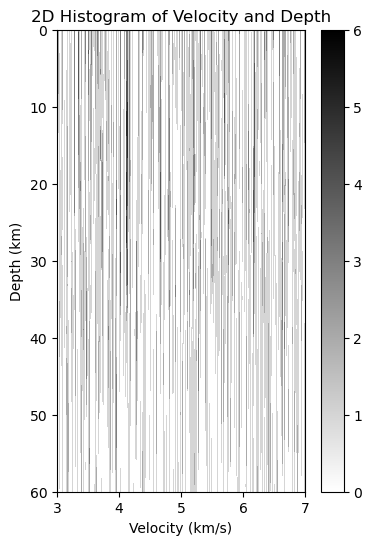

In [35]:
n_layers = 3

# create step profile
nsteps_to_profile = len(prior_inf_data_after_5000.posterior.draw.values)
step_profile = np.zeros((nsteps_to_profile*nwalkers, 1000))
depths = np.linspace(0, 60, 1000)

for step_i in range(nsteps_to_profile):
    for walker_j in range(nwalkers):
        for k in range(n_layers):
            thickness_key = f"thickness{k+1} (km)"
            velocity_key = f"velocity{k+1} (km/s)"
            thickness = prior_inf_data_after_5000.posterior[thickness_key].values[walker_j, step_i]
            velocity = prior_inf_data_after_5000.posterior[velocity_key].values[walker_j, step_i]
            depth_lower_bound = sum(prior_inf_data_after_5000.posterior[f"thickness{j+1} (km)"].values[walker_j, step_i] for j in range(k))
            depth_upper_bound = sum(prior_inf_data_after_5000.posterior[f"thickness{j+1} (km)"].values[walker_j, step_i] for j in range(k+1))
            step_profile[step_i*nwalkers+walker_j, (depths<depth_upper_bound)&(depths>depth_lower_bound)] = velocity

_, ax = plt.subplots(1, 1, figsize=(4,6))
hist, xedges, yedges, cbar = ax.hist2d(step_profile.flatten(), np.tile(depths, nsteps_to_profile*nwalkers), bins=1000, 
                                        cmap='binary', range=[[3,7],[0,60]])
ax.invert_yaxis()
ax.set_xlabel("Velocity (km/s)")
ax.set_ylabel("Depth (km)")
plt.colorbar(cbar)
plt.xlabel('Velocity (km/s)')
plt.ylabel('Depth (km)')
plt.title('2D Histogram of Velocity and Depth');

### 2.2 Enrich BaseProblem

Coming back to our original problem and trying to sample the posterior distribution.

In [24]:
my_problem.set_model_shape(ndim)
my_problem.set_log_likelihood(my_log_likelihood)
my_problem.set_log_prior(my_log_prior)

my_problem.summary()

Summary for inversion problem: BaseProblem
Model shape: 6
---------------------------------------------------------------------
List of functions/properties set by you:
['objective', 'log_likelihood', 'log_prior', 'initial_model', 'model_shape', 'blobs_dtype']
---------------------------------------------------------------------
List of functions/properties created based on what you have provided:
['log_posterior', 'log_posterior_with_blobs']
---------------------------------------------------------------------
List of functions/properties that can be further set for the problem:
( not all of these may be relevant to your inversion workflow )
['log_posterior', 'log_posterior_with_blobs', 'gradient', 'hessian', 'hessian_times_vector', 'residual', 'jacobian', 'jacobian_times_vector', 'data_misfit', 'regularization', 'regularization_matrix', 'forward', 'data', 'data_covariance', 'data_covariance_inv', 'bounds', 'constraints']


### 2.3 Define InversionOptions, Inversion and run

In [25]:
import warnings
warnings.filterwarnings("ignore")

my_options_sampler = cofi.InversionOptions()
my_options_sampler.set_tool("emcee")
my_options_sampler.set_params(
    nwalkers=nwalkers,
    nsteps=nsteps,
    initial_state=walkers_start,
    progress=True,
)
inv_sampler = cofi.Inversion(my_problem, my_options_sampler)
inv_result_sampler = inv_sampler.run()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [04:44<00:00, 87.84it/s]


In [26]:
inv_result_sampler.summary()

Summary for inversion result
SUCCESS
----------------------------
sampler: <emcee.ensemble.EnsembleSampler object>
blob_names: ['log_likelihood', 'log_prior']


### 2.4 Plot the sampling results

In [27]:
az_inf_data = inv_result_sampler.to_arviz(var_names=var_names)
az_inf_data

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior

#### Trace plot

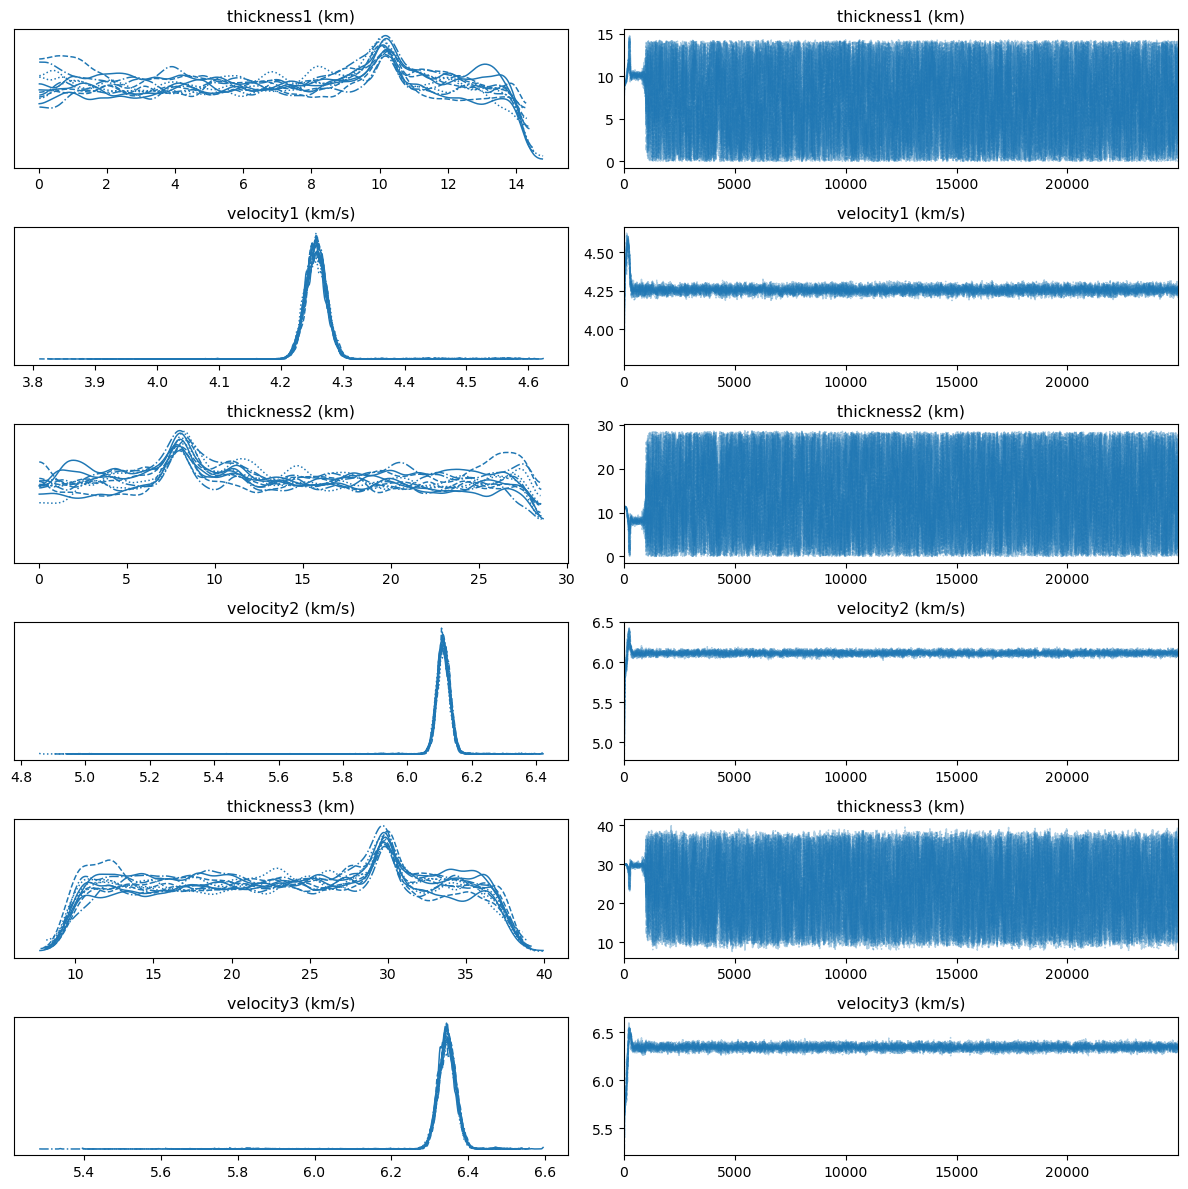

In [28]:
arviz.plot_trace(az_inf_data)
plt.tight_layout();

#### Autocorrelation time

The walkers start in small distributions around some chosen values and then they quickly wander and start exploring the full posterior distribution. In fact, after a relatively small number of steps, the samples seem pretty well “burnt-in”. That is a hard statement to make quantitatively, but we can look at an estimate of the integrated autocorrelation time (see Emcee's package the -[*Autocorrelation analysis & convergence tutorial*](https://emcee.readthedocs.io/en/stable/tutorials/autocorr/) for more details):

In [29]:
tau = inv_result_sampler.sampler.get_autocorr_time()
print(f"autocorrelation time: {tau}")

autocorrelation time: [129.90060325 166.671897   127.81564755  47.32166054 128.95411015
  83.38180096]


#### Corner plot

Let’s discard the initial 5000 steps, thin it by every 250 steps and make a corner plot:

Reference good model: [ 8.   4.2 20.   6.  45.   6.2]


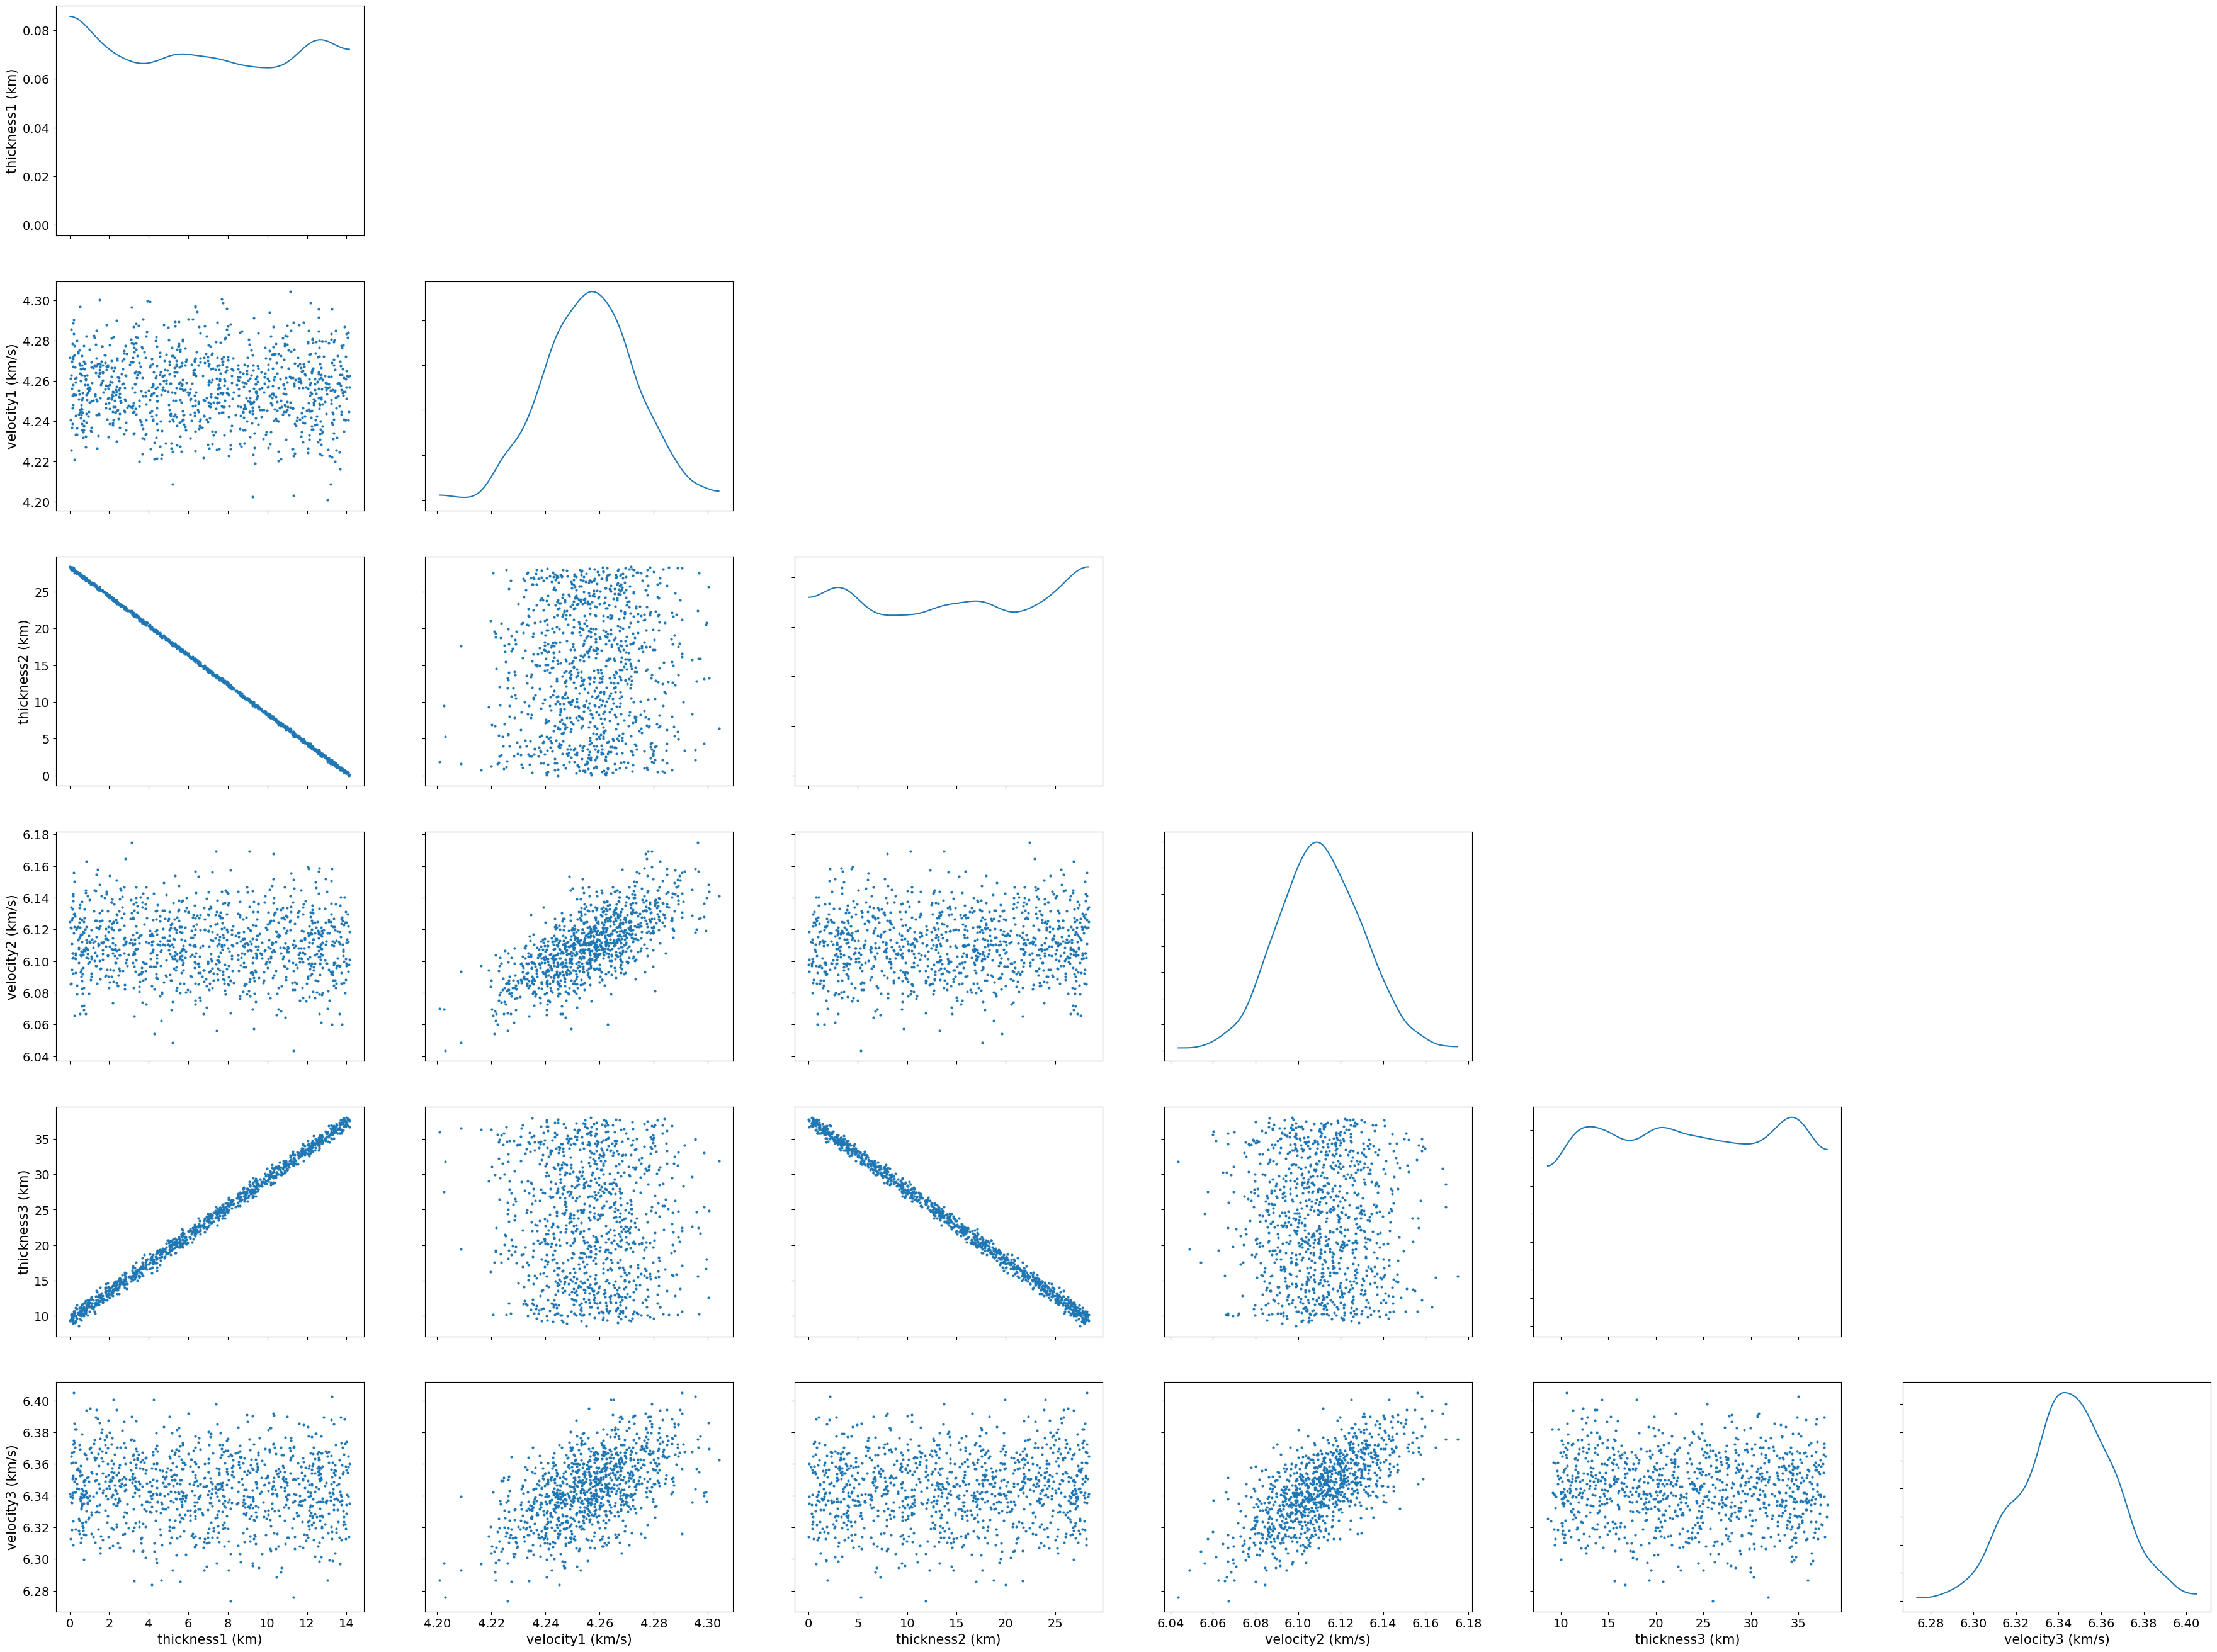

In [30]:
az_inf_data_after_5000 = az_inf_data.sel(draw=slice(3000,None,250))

arviz.plot_pair(
    az_inf_data_after_5000, 
    marginals=True, 
)

print("Reference good model:", my_receiver_function.good_model)

#### Mean sample

Mean of samples:      [ 6.9928819   4.25641952 21.35795425  6.11044428 44.78656661  6.34402404]
Reference good model: [ 8.   4.2 20.   6.  45.   6.2]


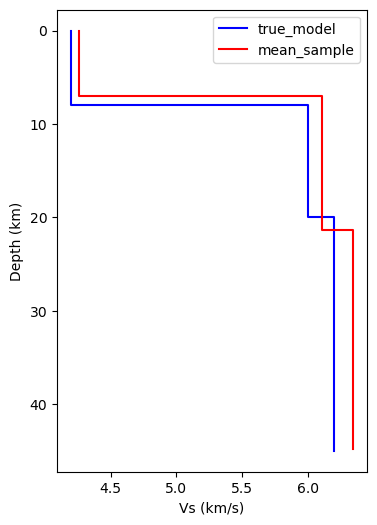

In [31]:
true_model = my_receiver_function.good_model
mean_sample = np.array(az_inf_data_after_5000["posterior"].mean().to_array())
mean_sample_model = thickness_to_depth(mean_sample)

print("Mean of samples:     ", mean_sample_model)
print("Reference good model:", true_model)

my_receiver_function.plot_model(true_model, mean_sample_model, "true_model", "mean_sample")
plt.legend();

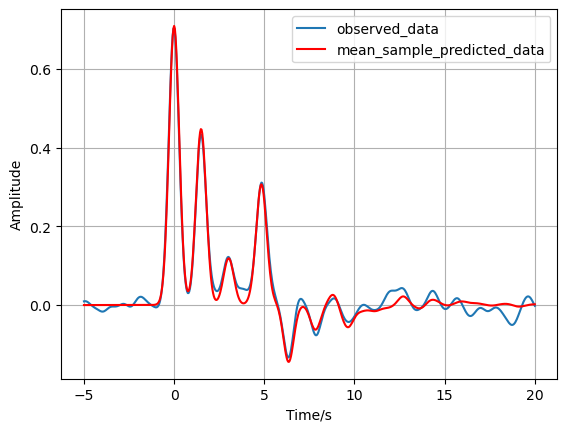

In [32]:
mean_sample_predicted_data = my_receiver_function.forward(mean_sample_model)
my_receiver_function.plot_data(
    observed_data, 
    mean_sample_predicted_data,
    "observed_data",
    "mean_sample_predicted_data",
);
plt.legend();

#### 1D profile histogram

Text(0.5, 1.0, '2D Histogram of Velocity and Depth')

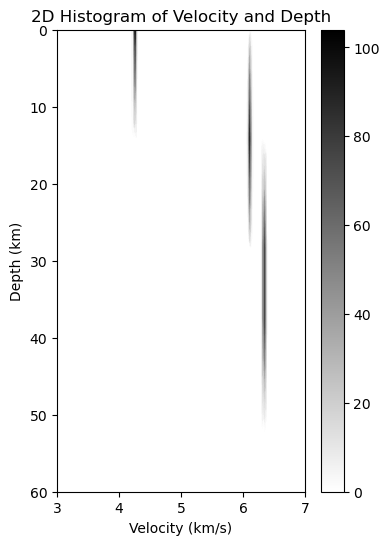

In [41]:
n_layers = 3

# create step profile
nsteps_to_profile = len(az_inf_data_after_5000.posterior.draw.values)
step_profile = np.zeros((nsteps_to_profile*nwalkers, 1000))
depths = np.linspace(0, 60, 1000)

for step_i in range(nsteps_to_profile):
    for walker_j in range(nwalkers):
        for k in range(n_layers):
            thickness_key = f"thickness{k+1} (km)"
            velocity_key = f"velocity{k+1} (km/s)"
            thickness = az_inf_data_after_5000.posterior[thickness_key].values[walker_j, step_i]
            velocity = az_inf_data_after_5000.posterior[velocity_key].values[walker_j, step_i]
            depth_lower_bound = sum(az_inf_data_after_5000.posterior[f"thickness{j+1} (km)"].values[walker_j, step_i] for j in range(k))
            depth_upper_bound = sum(az_inf_data_after_5000.posterior[f"thickness{j+1} (km)"].values[walker_j, step_i] for j in range(k+1))
            step_profile[step_i*nwalkers+walker_j, (depths<depth_upper_bound)&(depths>depth_lower_bound)] = velocity

_, ax = plt.subplots(1, 1, figsize=(4,6))
hist, xedges, yedges, cbar = ax.hist2d(step_profile.flatten(), np.tile(depths, nsteps_to_profile*nwalkers), bins=1000, 
                                       cmap='binary', range=[[3,7],[0,60]])
ax.invert_yaxis()
ax.set_xlabel("Velocity (km/s)")
ax.set_ylabel("Depth (km)")
plt.colorbar(cbar)
plt.xlabel('Velocity (km/s)')
plt.ylabel('Depth (km)')
plt.title('2D Histogram of Velocity and Depth');

In [ ]:
# plot the samples
_, ax = plt.subplots(1, 1, figsize=(4,6))
ax.set_xlabel('Vs (km/s)')
ax.set_ylabel('Depth (km)')
ax.invert_yaxis()

for step_i in range(nsteps_to_profile):
    for walker_j in range(nwalkers):
        model = np.zeros((my_receiver_function.model_size,))
        for k in range(n_layers):
            thickness_key = f"thickness{k+1} (km)"
            velocity_key = f"velocity{k+1} (km/s)"
            thickness = az_inf_data_after_5000.posterior[thickness_key].values[walker_j, step_i]
            velocity = az_inf_data_after_5000.posterior[velocity_key].values[walker_j, step_i]
            model[2*k] = thickness
            model[2*k+1] = velocity
            model = thickness_to_depth(model)
            model_setup = my_receiver_function._model_setup(model)
            px = np.zeros([2*len(model_setup),2])
            px[0::2,0] = model_setup[:,1]
            px[1::2,0] = model_setup[:,1]
            px[1::2,1] = model_setup[:,0]
            px[2::2,1] = model_setup[:-1,0]
            ax.plot(px[:,0], px[:,1],'k',linewidth=0.1)

---
## Watermark

<!-- Feel free to add more modules in the watermark_list below, if more packages are used -->
<!-- Otherwise please leave the below code cell unchanged -->

In [34]:
watermark_list = ["cofi", "espresso", "numpy", "matplotlib", "emcee", "arviz"]
for pkg in watermark_list:
    pkg_var = __import__(pkg)
    print(pkg, getattr(pkg_var, "__version__"))

cofi 0.2.2
espresso 0.3.9
numpy 1.23.5
matplotlib 3.7.1
emcee 3.1.4
arviz 0.15.1
